In [ ]:
%load_ext autoreload
%autoreload 2
import os, pickle, time
import numpy as np
import pandas as pd
import networkx as nx
import prince

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
version3_path = os.path.join(parent_dir, "Version3")
os.chdir(version3_path)   # 借用 Version3 的 tdamapper / utils / Data

from sklearn.cluster import AgglomerativeClustering
from tdamapper.core_old import MapperAlgorithm
from tdamapper.cover import CubicalCover
from tdamapper.clustering import FailSafeClustering
from utils.preprocess import preprocess, process_other

# 載入新版 models.py（Version3/utils 沒有 models，用檔案路徑載）
import importlib.util
_mp = os.path.join(parent_dir, "Models", "utils", "models.py")
_spec = importlib.util.spec_from_file_location("models_new", _mp)
models_new = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(models_new)
_ev = os.path.join(parent_dir, "Models", "utils", "evaluate.py")
_spec2 = importlib.util.spec_from_file_location("evaluate", _ev)
evaluate = importlib.util.module_from_spec(_spec2); _spec2.loader.exec_module(evaluate)

dataA2 = pd.read_csv("./Data/A2.csv", low_memory=False)
dataA1 = pd.read_csv("./Data/A1.csv")

In [ ]:
select_lst = [
    # 月份是為了篩選每個月2萬筆
    '發生月份',

    '天候名稱', '光線名稱', 
    '道路類別-第1當事者-名稱', '速限-第1當事者', 
    # '路面狀況-路面鋪裝名稱', '路面狀況-路面狀態名稱', '路面狀況-路面缺陷名稱',
    # '道路障礙-障礙物名稱', '道路障礙-視距品質名稱', '道路障礙-視距名稱',
    '號誌-號誌種類名稱', '號誌-號誌動作名稱',
    '車道劃分設施-分道設施-快車道或一般車道間名稱', '車道劃分設施-分道設施-快慢車道間名稱', '車道劃分設施-分道設施-路面邊線名稱',
    '當事者屬-性-別名稱', '當事者事故發生時年齡',
    '保護裝備名稱', '行動電話或電腦或其他相類功能裝置名稱',
    # '肇事逃逸類別名稱-是否肇逃',
    '死亡受傷人數',

    # 大類別
    '道路型態大類別名稱', '事故位置大類別名稱',
    '車道劃分設施-分向設施大類別名稱',
    '事故類型及型態大類別名稱', '當事者區分-類別-大類別名稱-車種', #'當事者行動狀態大類別名稱',
    # '車輛撞擊部位大類別名稱-最初', '車輛撞擊部位大類別名稱-其他',
    
    # 子類別
    '道路型態子類別名稱', '事故位置子類別名稱', '當事者行動狀態子類別名稱',
    # '事故類型及型態子類別名稱', '肇因研判子類別名稱-主要', '當事者行動狀態子類別名稱', '當事者區分-類別-子類別名稱-車種', 
    # '車輛撞擊部位子類別名稱-最初', '車輛撞擊部位子類別名稱-其他', '肇因研判子類別名稱-個別', '肇因研判子類別名稱-主要'
]

# OSM Jenks 是 preprocess 後才生成的欄位，會在後面加入 mapper_select_lst；原始經緯度不加入。
full_dataA1 = preprocess(dataA1, target='全部', lst=select_lst, add_features=True)
full_dataA2 = preprocess(dataA2, target='全部', lst=select_lst, add_features=True)
# add_features=True 會多出：對造車種/當事人數/有無大型車、時段/深夜/週末/季節（無洩漏）
mapper_numpy, rbind_data, dummy_data, death, injuried, date_info = process_other(
    full_dataA1, full_dataA2, downsample=False, en=False, return_time=True)
print('rbind_data:', rbind_data.shape, '| dummy:', dummy_data.shape)

In [ ]:
# ==== 表示學習先依時間切分：前 70% 建 MCA/Mapper，後 30% 是 OOS pool ====
# OOS pool 會在模型階段再依時間分成 10% validation + 20% final test。
TRAIN_FRAC = 0.70
VALIDATION_FRAC = 0.10
TEST_FRAC = 0.20
_n = len(rbind_data)
_order_index = date_info.sort_values(['發生日期', '發生時間']).index
_order_pos = rbind_data.index.get_indexer(_order_index)
if (_order_pos < 0).any():
    raise ValueError('date_info 與 rbind_data 的 index 無法對齊')
_n_train = int(np.floor(_n * TRAIN_FRAC))
_n_validation = int(np.floor(_n * VALIDATION_FRAC))
_validation_end = _n_train + _n_validation
train_pos = _order_pos[:_n_train]
validation_pos = _order_pos[_n_train:_validation_end]
final_test_pos = _order_pos[_validation_end:]
test_pos = _order_pos[_n_train:]  # Mapper OOS pool = validation + final test
print('time split | train:', len(train_pos),
      '| validation:', len(validation_pos),
      '| final test:', len(final_test_pos),
      '| Mapper OOS pool:', len(test_pos))

In [ ]:
# ==== OSM 地理特徵：原始經緯度只用來算距離；所有補值與 Jenks 分界只用 train ====
import geopandas as gpd
from sklearn.neighbors import BallTree
import jenkspy

OSM_DIR = "/Users/wangqiqian/Desktop/QGIS/taiwan-251009-free.shp"
R_KM = 6371.0088

def _latlon_rad(gdf):
    g = gdf.copy()
    if g.crs is not None and g.crs.to_epsg() != 4326:   # 若非 WGS84 就轉（本資料已是 4326，不需 transform）
        g = g.to_crs(4326)
    pts = g.geometry.representative_point()             # 點層回傳點本身；面層回傳內部代表點
    return np.radians(np.c_[pts.y.values, pts.x.values])

# 醫院：點層 + 面層
_h1 = gpd.read_file(f"{OSM_DIR}/gis_osm_pois_free_1.shp");   _h1 = _h1[_h1['fclass'] == 'hospital']
_h2 = gpd.read_file(f"{OSM_DIR}/gis_osm_pois_a_free_1.shp"); _h2 = _h2[_h2['fclass'] == 'hospital']
hosp_rad = np.vstack([_latlon_rad(_h1), _latlon_rad(_h2)])

# 城鎮（city/town）與 有人口的地點
_places = gpd.read_file(f"{OSM_DIR}/gis_osm_places_free_1.shp")
city_rad = _latlon_rad(_places[_places['fclass'].isin(['city', 'town'])])
_pop = _places[_places['population'] > 0]
pop_rad = _latlon_rad(_pop)
pop_val = _pop['population'].to_numpy()

# 事故座標（來自 date_info，與 rbind_data 對齊）；濾掉台灣範圍外的錯誤座標
lat = pd.to_numeric(date_info['緯度'], errors='coerce').to_numpy()
lon = pd.to_numeric(date_info['經度'], errors='coerce').to_numpy()
valid = np.isfinite(lat) & np.isfinite(lon) & (lat > 20) & (lat < 26.5) & (lon > 118) & (lon < 122.5)
acc_rad = np.radians(np.c_[np.where(valid, lat, 0.0), np.where(valid, lon, 0.0)])

def _nearest(tree_pts):
    d, i = BallTree(tree_pts, metric='haversine').query(acc_rad, k=1)
    return d[:, 0] * R_KM, i[:, 0]

d_h, _   = _nearest(hosp_rad)     # 最近醫院距離(km) = 送醫可及性
d_c, _   = _nearest(city_rad)     # 最近城鎮距離(km) = 城鄉
d_p, i_p = _nearest(pop_rad)      # 最近有人口地點 → 取其人口

spatial_raw = pd.DataFrame({
    'dist_hospital_band': np.where(valid, d_h, np.nan),
    'dist_city_band':     np.where(valid, d_c, np.nan),
    'nearest_pop_band':   np.where(valid, pop_val[i_p], np.nan),
}, index=rbind_data.index)
print(spatial_raw.describe().T[['mean', '50%', 'max']])

def jenks_bin_train(series, train_positions, n_classes=5, sample=20000, random_state=42):
    """只用 train 補值並估 Jenks 內部分界，再套用到全體；輸出皆為類別字串。"""
    v = pd.to_numeric(series, errors='coerce')
    tr = v.iloc[train_positions].dropna()
    if tr.empty:
        raise ValueError(f'{series.name} 的 train 資料全為缺值')
    v = v.fillna(tr.median())
    tr = v.iloc[train_positions]
    k = min(n_classes, tr.nunique())
    if k < 2:
        return pd.Series('L1', index=v.index, dtype=object)
    s = tr.sample(min(len(tr), sample), random_state=random_state) if len(tr) > sample else tr
    try:
        breaks = jenkspy.jenks_breaks(s.values, n_classes=k)
    except TypeError:
        breaks = jenkspy.jenks_breaks(s.values, nb_class=k)
    breaks = sorted(set(float(b) for b in breaks))
    if len(breaks) < 3:
        return pd.Series('L1', index=v.index, dtype=object)
    breaks[0], breaks[-1] = -np.inf, np.inf
    labels = [f"L{i+1}" for i in range(len(breaks) - 1)]
    return pd.cut(v, bins=breaks, labels=labels, include_lowest=True).astype(str)

GEO_MAPPER_COLS = list(spatial_raw.columns)
spatial_df = pd.DataFrame(index=rbind_data.index)
for _col in GEO_MAPPER_COLS:
    spatial_df[_col] = jenks_bin_train(spatial_raw[_col], train_pos, n_classes=5)

print('train-only spatial Jenks 完成:', GEO_MAPPER_COLS)
display(spatial_df.apply(lambda s: s.value_counts().sort_index()))

In [ ]:
# ==== 合併回完整檔並依時間排序、存檔 ====
base = rbind_data.copy()
base['死亡'] = death.values
base = pd.concat([base, spatial_df], axis=1)
base['發生日期'] = date_info['發生日期'].values
base['發生時間'] = date_info['發生時間'].values

order = _order_index
base = base.loc[order].reset_index(drop=True)
full_notopo = base.copy()

os.makedirs('./Data/FullData', exist_ok=True)
full_notopo.to_csv('./Data/FullData/full_no_topo.csv', index=False)

In [ ]:
# ==== 訓練：時間順序 70% train / 10% validation / 20% test ====
# 重新載入 models.py，確保目前 kernel 使用 validation-threshold 新版函式。
_spec.loader.exec_module(models_new)
DROP = [c for c in ['發生日期', '發生時間'] if c in full_notopo.columns]
X_notopo, y_notopo = models_new.get_train_test_data(full_notopo.drop(columns=DROP).copy())

SEED = 42
TRAIN_UNDER_RATIO = 1
ENCODING = 'onehot'
THRESHOLD_STRATEGY = 'youden'
RESULT_ROOT = '../Models/ModelPerformanceSeed/validation_youden_70_10_20'
_n_model = len(X_notopo)
assert len(final_test_pos) == _n_model - len(train_pos) - len(validation_pos)
print('model split | train:', int(np.floor(_n_model * TRAIN_FRAC)),
      '| validation:', int(np.floor(_n_model * VALIDATION_FRAC)),
      '| test:', _n_model - int(np.floor(_n_model * TRAIN_FRAC))
                   - int(np.floor(_n_model * VALIDATION_FRAC)))
algos = [('xgboost', models_new.xgboost_cm_gridsearch),
         ('logistic', models_new.logistic_cm_gridsearch),
         ('svc', models_new.linear_svc_cm_gridsearch)]

def train_and_save_variant(tag, X, y, result_root):
    """固定 70/10/20，並在 validation 自動選擇 Youden's J 最大的 threshold。"""
    for algo_name, fn in algos:
        print(f'[{tag}] {algo_name} start')
        t = time.time()
        yv, sc, idx, threshold_info = fn(
            X, y,
            random_state=SEED,
            encoding=ENCODING,
            train_under_ratio=TRAIN_UNDER_RATIO,
            threshold_strategy=THRESHOLD_STRATEGY,
            train_frac=TRAIN_FRAC,
            validation_frac=VALIDATION_FRAC,
        )
        elapsed = time.time() - t
        save_dir = f"{result_root}/{tag}/{algo_name}"
        os.makedirs(save_dir, exist_ok=True)
        with open(f"{save_dir}/full.pkl", "wb") as f:
            pickle.dump({
                'y': yv,
                'decision_scores': sc,
                'indices': idx,
                'elapsed_time': elapsed,
                'selected_threshold': threshold_info['selected_threshold'],
                'threshold_selection': threshold_info,
                'features': X.columns.tolist(),
                'time_split': {
                    'train': TRAIN_FRAC,
                    'validation': VALIDATION_FRAC,
                    'test': 1 - TRAIN_FRAC - VALIDATION_FRAC,
                },
            }, f)
        print(
            f'[{tag}] {algo_name} done in {elapsed:.1f}s | '
            f"threshold={threshold_info['selected_threshold']:.4f} | "
            f"val J={threshold_info['validation_youden_j']:.4f} | "
            f"recall={threshold_info['validation_recall']:.4f} | "
            f"specificity={threshold_info['validation_specificity']:.4f} | "
            f"precision={threshold_info['validation_precision']:.4f} | "
            f"F1={threshold_info['validation_f1']:.4f}"
        )

MAIN_VARIANTS = {
    'full_notopo': (X_notopo, y_notopo),
}
for tag, (X, y) in MAIN_VARIANTS.items():
    train_and_save_variant(tag, X, y, RESULT_ROOT)

In [93]:
_spec2.loader.exec_module(evaluate)
rows = []
for algo_name, _ in algos:
    for tag in ['full_notopo']:
        path = f"{RESULT_ROOT}/{tag}/{algo_name}/full.pkl"
        d = evaluate.load_pkl(path)
        m = evaluate.metrics_from_pkl(path, threshold='saved')
        rows.append((f"{algo_name} | {tag}", m))

print('Test metrics（threshold 已在 validation 固定）')
display(evaluate.build_table(rows))
print('Validation threshold audit')

Test metrics（threshold 已在 validation 固定）


,pr_auc,roc_auc,balanced_acc,recall,precision,f1,accuracy,threshold,n_test
method,,,,,,,,,
xgboost | full_notopo,0.0391,0.8375,0.7637,0.7543,0.0151,0.0297,0.7730,0.5293,62787
logistic | full_notopo,0.0393,0.8351,0.7605,0.7232,0.0163,0.0318,0.7975,0.5069,62787
svc | full_notopo,0.0402,0.8367,0.7613,0.7716,0.0141,0.0278,0.7512,-0.1503,62787


Validation threshold audit


## Feature Importance (All 3 Models: xgboost / logistic / svc)

Mapper is not fed into the model. Model performance comparison stays as-is above (`full_notopo`). This section runs SHAP feature importance for **all three** trained algorithms, so we can also check whether the important features are consistent across model choice, not just check one model's stability.

**Randomness source, as requested:** the only thing varied across repeats is the training-set `RandomUnderSampler` draw (`TRAIN_UNDER_RATIO=1` balances the majority/minority class 1:1) — each repeat's model faces a different random sample of non-death cases. The SHAP evaluation sample (20,000 rows from the held-out test set) is fixed across all repeats/algos, so what varies is purely which no-death training examples the model was trained on (plus, for xgboost, its own internal subsample/colsample stochasticity, which is unavoidable once `random_state` changes).

**Resolved from earlier:** `死亡受傷人數` is split into `死亡`/`受傷` and both raw columns are dropped before modeling — confirmed it never reaches `X_notopo`, so it's not a leakage feature.

**Metric caveat still stands:** xgboost leads on ROC-AUC/balanced_acc, svc leads on PR-AUC/F1, all three are close. State which metric "best" is based on when you write this up.

In [94]:
import shap
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

FEATURE_NAME_EN = {
    'other_vehicle': 'Other Vehicle Type',
    '速限-第1當事者': 'Speed Limit - First Party',
    '道路類別-第1當事者-名稱': 'Road Category - First Party - Name',
    '保護裝備名稱': 'Protective Equipment',
    '當事者區分-類別-大類別名稱-車種': 'Party Classification - Vehicle Type',
    'hour_band': 'Hour Band',
    'has_heavy_vehicle': 'Has Heavy Vehicle',
    '當事者事故發生時年齡': 'Party Age at Accident',
    'dist_hospital_band': 'Distance to Hospital (Band)',
    '車道劃分設施-分向設施大類別名稱': 'Lane Division Facility - Major Category',
    'nearest_pop_band': 'Nearest Settlement Population (Band)',
    'dist_city_band': 'Distance to City (Band)',
    '天候名稱': 'Weather Condition',
    '當事者行動狀態大類別名稱': 'Party Action Status - Major Category',
    '事故位置大類別名稱': 'Accident Location - Major Category',
    '車道劃分設施-分道設施-快車道或一般車道間名稱': 'Lane Division Facility - Between Fast and General Lanes',
    'season': 'Season',
    'has_pedestrian': 'Has Pedestrian',
    '事故類型及型態大類別名稱': 'Accident Type and Form - Major Category',
    'is_night': 'Is Night',
    '光線名稱': 'Lighting Condition',
    '車道劃分設施-分道設施-快慢車道間名稱': 'Lane Division Facility - Between Fast and Slow Lanes',
    '道路障礙-視距名稱': 'Road Obstruction - Sight Distance',
    '號誌-號誌種類名稱': 'Traffic Signal - Signal Type',
    '道路障礙-障礙物名稱': 'Road Obstruction - Obstacle Type',
    '當事者屬-性-別名稱': 'Party Attribute - Gender',
    '道路障礙-視距品質名稱': 'Road Obstruction - Visibility Quality',
    '路面狀況-路面缺陷名稱': 'Road Surface Condition - Surface Defects',
    '路面狀況-路面狀態名稱': 'Road Surface Condition - Surface State',
    'n_parties': 'Number of Parties',
    '號誌-號誌動作名稱': 'Traffic Signal - Signal Operation',
    '行動電話或電腦或其他相類功能裝置名稱': 'Mobile Phone, Computer, or Other Similar Devices',
    'has_motorcycle': 'Has Motorcycle',
    '道路型態大類別名稱': 'Road Category - Major Category',
    '車道劃分設施-分道設施-路面邊線名稱': 'Lane Division Facility - Road Edge Line',
    'is_weekend': 'Is Weekend',
    '路面狀況-路面鋪裝名稱': 'Road Surface Condition - Pavement Type',

    # 子類別（新加入模型特徵）
    '道路型態子類別名稱': 'Road Category - Subcategory',
    '事故位置子類別名稱': 'Accident Location - Subcategory',
    '當事者行動狀態子類別名稱': 'Party Action Status - Subcategory',
}

def to_english(name):
    if name in FEATURE_NAME_EN:
        return FEATURE_NAME_EN[name]
    print(f'[warn] no English mapping for feature: {name!r} — falling back to a cleaned-up label')
    return name.replace('_', ' ').title()

def _match_original_col(oh_name, cat_cols):
    # OneHotEncoder output format is "<original_col>_<category>"; match the longest original
    # column name that is a prefix, to avoid collisions when one column name is a prefix of another.
    candidates = [c for c in cat_cols if oh_name == c or oh_name.startswith(c + '_')]
    return max(candidates, key=len) if candidates else oh_name

# Time-based split itself is deterministic; only the training-set RandomUnderSampler depends on
# random_state. Fixing X_test / the SHAP sample here means every repeat/algo below explains the
# exact same rows — any variation you see comes purely from which training rows were undersampled.
_, _, X_test_shap, _, _, y_test_shap = models_new._prepare_train_validation_test(
    X_notopo, y_notopo, encoding=ENCODING, random_state=SEED,
    train_under_ratio=TRAIN_UNDER_RATIO, train_frac=TRAIN_FRAC, validation_frac=VALIDATION_FRAC,
)
SHAP_SAMPLE_N = min(20000, X_test_shap.shape[0])
eval_idx = np.random.RandomState(SEED).choice(X_test_shap.shape[0], SHAP_SAMPLE_N, replace=False)
X_eval_fixed = X_test_shap.iloc[eval_idx]
y_eval_fixed = y_test_shap.iloc[eval_idx]
print('Fixed SHAP evaluation sample size:', X_eval_fixed.shape[0])

# Copied from the "Best parameters" printed by RandomizedSearchCV for [full_notopo], clf__ stripped
ALGO_BEST_PARAMS = {
    'xgboost': dict(n_estimators=400, max_depth=5, learning_rate=0.2,
                     colsample_bytree=0.6, subsample=0.8),
    'logistic': dict(penalty='l2', C=0.01),
    'svc': dict(loss='hinge', C=0.01),
}
ALGOS = ['xgboost', 'logistic', 'svc']

Fixed SHAP evaluation sample size: 20000


/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [95]:
def _build_classifier(algo, seed, y_train_i):
    if algo == 'xgboost':
        pos = max(int((y_train_i == 1).sum()), 1)
        neg = int((y_train_i == 0).sum())
        return XGBClassifier(tree_method='hist', eval_metric='logloss',
                              scale_pos_weight=neg / pos, n_jobs=1, random_state=seed,
                              **ALGO_BEST_PARAMS['xgboost'])
    if algo == 'logistic':
        return LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced',
                                   random_state=seed, **ALGO_BEST_PARAMS['logistic'])
    if algo == 'svc':
        return LinearSVC(class_weight='balanced', max_iter=100000, random_state=seed,
                          **ALGO_BEST_PARAMS['svc'])
    raise ValueError(f'unknown algo: {algo}')

def _fit_and_analyze(seed, algo):
    X_train_i, X_validation_i, X_test_i, y_train_i, y_validation_i, y_test_i = \
        models_new._prepare_train_validation_test(
            X_notopo, y_notopo, encoding=ENCODING, random_state=seed,
            train_under_ratio=TRAIN_UNDER_RATIO, train_frac=TRAIN_FRAC, validation_frac=VALIDATION_FRAC,
        )
    clf_i = _build_classifier(algo, seed, y_train_i)
    pipe_i = models_new._wrap(clf_i, ENCODING)
    pipe_i.fit(X_train_i, y_train_i)

    def _scores(df):
        return pipe_i.predict_proba(df)[:, 1] if algo != 'svc' else pipe_i.decision_function(df)

    # --- test metrics: threshold selected on this seed's own validation split (Youden's J) ---
    threshold_info_i = models_new.select_threshold_youden(y_validation_i, _scores(X_validation_i))
    metrics_i = evaluate.metrics_from_arrays(
        y_test_i, _scores(X_test_i), threshold=threshold_info_i['selected_threshold'])

    # --- SHAP importance: explain the fixed evaluation sample with this same fitted model ---
    pre_i = pipe_i.named_steps['pre']
    clf_fitted_i = pipe_i.named_steps['clf']
    cat_cols_i, num_cols_i = [], []
    for name, trans, cols in pre_i.transformers_:
        if name == 'oh':
            cat_cols_i = list(cols)
        elif name == 'num':
            num_cols_i = list(cols)
    oh_names_i = list(pre_i.named_transformers_['oh'].get_feature_names_out(cat_cols_i))
    source_i = [_match_original_col(n, cat_cols_i) for n in oh_names_i] + list(num_cols_i)
    level_names_i = oh_names_i + list(num_cols_i)

    def _transform(df):
        t = pre_i.transform(df)
        if hasattr(t, 'toarray'):
            t = t.toarray()
        return pd.DataFrame(t, columns=level_names_i)

    X_eval_df = _transform(X_eval_fixed)
    if algo == 'xgboost':
        explainer_i = shap.TreeExplainer(clf_fitted_i)
    else:
        bg_n = min(200, X_train_i.shape[0])
        bg_idx = np.random.RandomState(seed).choice(X_train_i.shape[0], bg_n, replace=False)
        explainer_i = shap.LinearExplainer(clf_fitted_i, _transform(X_train_i.iloc[bg_idx]))

    shap_values_i = explainer_i.shap_values(X_eval_df)
    if isinstance(shap_values_i, list):  # some shap/xgboost version combos return [class0, class1]
        shap_values_i = shap_values_i[1]
    mean_abs_i = np.abs(shap_values_i).mean(axis=0)
    detail_i = pd.DataFrame({'original_feature': source_i, 'mean_abs_shap': mean_abs_i})
    importance_i = detail_i.groupby('original_feature')['mean_abs_shap'].sum()

    return metrics_i, importance_i

In [96]:
# ==== Run N_REPEATS seeds x 3 algos ONCE, collecting both metrics and SHAP importance ====
N_REPEATS = 10  # drop to 3 only if you specifically need exactly three runs (std will be noisy)
SEEDS = [SEED + i for i in range(N_REPEATS)]

metric_rows = {algo: [] for algo in ALGOS}
importance_rows = {algo: [] for algo in ALGOS}

for algo in ALGOS:
    print(f'=== {algo} ===')
    for seed in SEEDS:
        metrics_i, importance_i = _fit_and_analyze(seed, algo)
        metric_rows[algo].append(metrics_i)
        importance_rows[algo].append(importance_i)
        print(f'  seed={seed} | roc_auc={metrics_i["roc_auc"]:.4f} pr_auc={metrics_i["pr_auc"]:.4f} '
              f'recall={metrics_i["recall"]:.4f} precision={metrics_i["precision"]:.4f} f1={metrics_i["f1"]:.4f}')

importance_matrices = {}
for algo in ALGOS:
    imp = pd.concat(importance_rows[algo], axis=1).T
    imp.index = SEEDS
    importance_matrices[algo] = imp.fillna(0.0)

=== xgboost ===


/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


  seed=42 | roc_auc=0.8427 pr_auc=0.0392 recall=0.7958 precision=0.0143 f1=0.0282


/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


  seed=43 | roc_auc=0.8233 pr_auc=0.0387 recall=0.7751 precision=0.0132 f1=0.0260


...

  seed=49 | roc_auc=0.8349 pr_auc=0.0404 recall=0.8478 precision=0.0107 f1=0.0212


/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


  seed=50 | roc_auc=0.8411 pr_auc=0.0447 recall=0.7474 precision=0.0156 f1=0.0306


/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


  seed=51 | roc_auc=0.8383 pr_auc=0.0387 recall=0.7024 precision=0.0178 f1=0.0348


In [155]:
# ==== Test metrics, mean +/- std over N_REPEATS seeds ====
METRIC_COLS = ['pr_auc', 'roc_auc', 'balanced_acc', 'recall', 'precision', 'f1', 'accuracy', 'threshold']

def _mean_std_str(values):
    arr = np.asarray(values, dtype=float)
    return f'{arr.mean():.4f} \u00b1 {arr.std():.4f}'

summary_rows = []
for algo in ALGOS:
    dicts = metric_rows[algo]
    row = {'method': f'{algo} | full_notopo'}
    for col in METRIC_COLS:
        row[col] = _mean_std_str([d[col] for d in dicts])
    row['n_test'] = dicts[0]['n_test']
    summary_rows.append(row)

print(f"Test metrics, mean +/- std over {N_REPEATS} seeds "
      f"(threshold selected per-seed on validation via Youden's J)")

df = pd.DataFrame(summary_rows).set_index('method')
df[['pr_auc', 'roc_auc', 'balanced_acc', 'recall']].to_csv(f"{RESULT_ROOT}/summary_metrics.csv")

Test metrics, mean +/- std over 10 seeds (threshold selected per-seed on validation via Youden's J)


In [156]:
# ==== Save SHAP feature-importance summaries + cross-model rank comparison (no display here) ====
# Kept as CSVs for the write-up; only the boxplot below is shown inline per your requested order.
summaries = {}
for algo in ALGOS:
    imp = importance_matrices[algo]
    s = pd.DataFrame({
        'original_feature': imp.columns,
        'mean_abs_shap': imp.mean(axis=0).values,
        'std_abs_shap': imp.std(axis=0).values,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    s['share_%'] = (100 * s['mean_abs_shap'] / s['mean_abs_shap'].sum()).round(2)
    s['feature'] = s['original_feature'].map(to_english)
    summaries[algo] = s

    save_dir = f'{RESULT_ROOT}/full_notopo/{algo}/shap'
    os.makedirs(save_dir, exist_ok=True)
    s[['feature', 'mean_abs_shap', 'std_abs_shap', 'share_%']].round(4).to_csv(
        f'{save_dir}/feature_importance_mean_std.csv', index=False)
    imp.rename(columns=to_english).to_csv(f'{save_dir}/feature_importance_by_repeat.csv')

rank_table = None
for algo in ALGOS:
    s = summaries[algo][['original_feature', 'mean_abs_shap']].copy()
    s[f'rank_{algo}'] = s['mean_abs_shap'].rank(ascending=False, method='min').astype(int)
    s = s[['original_feature', f'rank_{algo}']]
    rank_table = s if rank_table is None else rank_table.merge(s, on='original_feature', how='outer')
rank_cols = [f'rank_{a}' for a in ALGOS]
rank_table['feature'] = rank_table['original_feature'].map(to_english)
rank_table['rank_std'] = rank_table[rank_cols].std(axis=1).round(2)
rank_table = rank_table[['feature'] + rank_cols + ['rank_std']].sort_values('rank_std')
corr_matrix = rank_table[rank_cols].corr(method='spearman').round(3)

compare_dir = f'{RESULT_ROOT}/full_notopo/shap_comparison'
os.makedirs(compare_dir, exist_ok=True)
rank_table.to_csv(f'{compare_dir}/rank_comparison_across_models.csv', index=False)
corr_matrix.to_csv(f'{compare_dir}/rank_spearman_correlation.csv')
print(f'Saved SHAP summaries to .../full_notopo/{{algo}}/shap/ and comparison to {compare_dir}')

Saved SHAP summaries to .../full_notopo/{algo}/shap/ and comparison to ../Models/ModelPerformanceSeed/validation_youden_70_10_20/full_notopo/shap_comparison


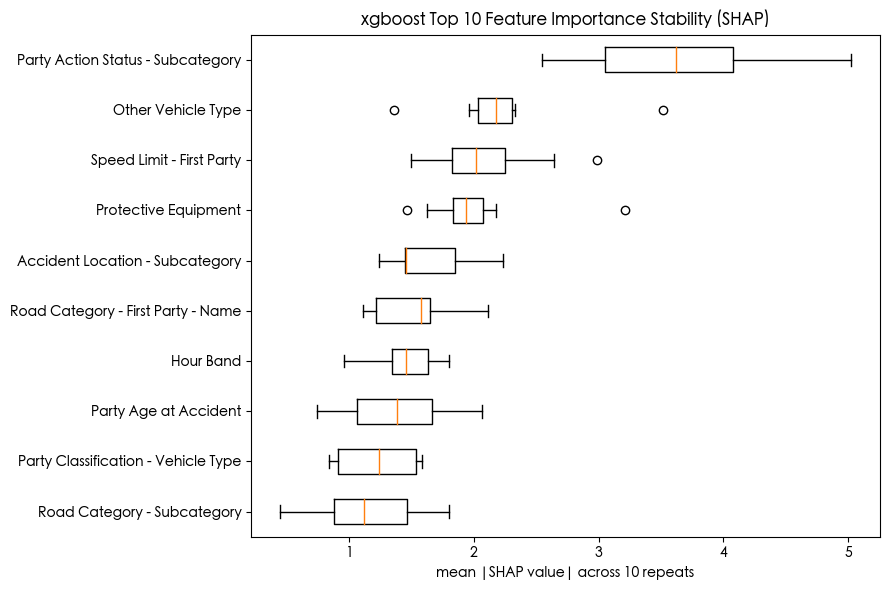

Saved to ../Models/ModelPerformanceSeed/validation_youden_70_10_20/full_notopo/xgboost/shap/feature_importance_boxplot.png


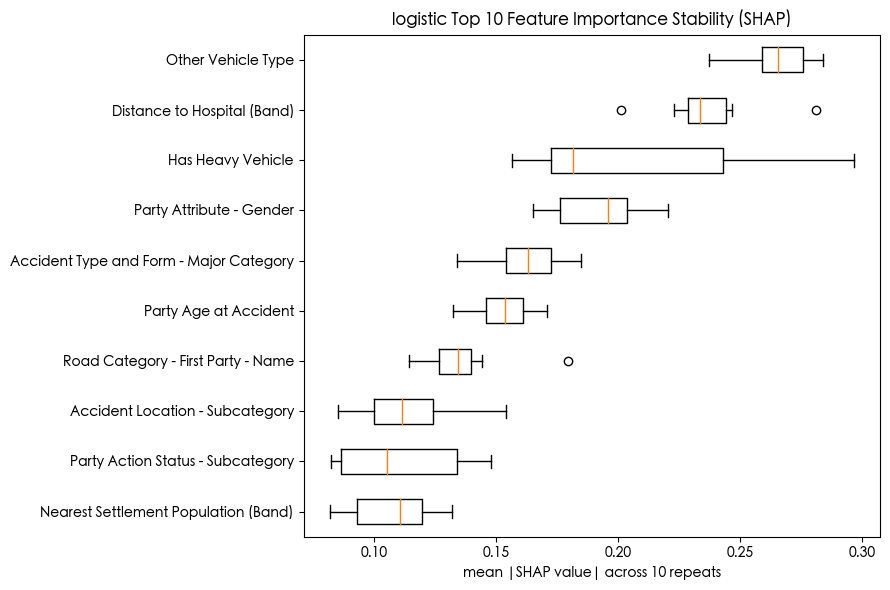

Saved to ../Models/ModelPerformanceSeed/validation_youden_70_10_20/full_notopo/logistic/shap/feature_importance_boxplot.png


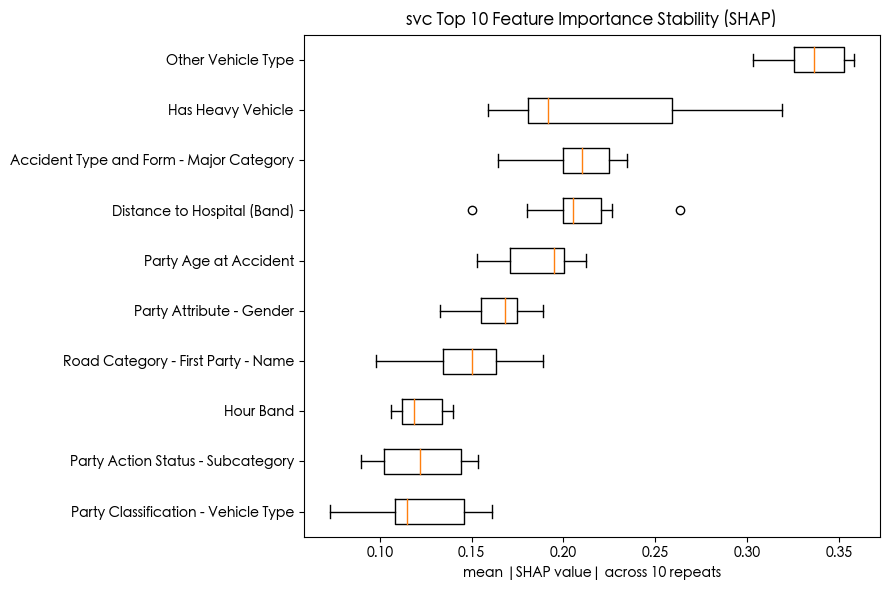

Saved to ../Models/ModelPerformanceSeed/validation_youden_70_10_20/full_notopo/svc/shap/feature_importance_boxplot.png


In [157]:
# ==== SHAP feature-importance boxplot per algo (one box per feature, across N_REPEATS) ====
import matplotlib.pyplot as plt

for algo in ALGOS:
    imp = importance_matrices[algo]
    s = summaries[algo]
    
    # 加上 [:10] 只取前10名
    top_n = 10
    ordered_original = s['original_feature'].tolist()[:top_n]  
    ordered_labels = s['feature'].tolist()[:top_n]
    
    # 這裡的 box_data 自動只會裝前 10 個特徵的數據
    box_data = [imp[col].values for col in ordered_original]

    # 圖表高度也會根據前10名自動調整
    fig_h = max(6, 0.35 * len(ordered_labels))
    fig, ax = plt.subplots(figsize=(9, fig_h))
    ax.boxplot(box_data, vert=False, labels=ordered_labels, showfliers=True)
    ax.set_xlabel(f'mean |SHAP value| across {N_REPEATS} repeats')
    ax.set_title(f'{algo} Top {top_n} Feature Importance Stability (SHAP)')
    ax.invert_yaxis()  # highest-importance feature on top
    fig.tight_layout()
    
    save_dir = f'{RESULT_ROOT}/full_notopo/{algo}/shap'
    fig.savefig(f'{save_dir}/feature_importance_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {save_dir}/feature_importance_boxplot.png')

### When comparing against Mapper

1. Define quantitatively what "visually important" means on the Mapper side (the lens/filter variables, or the features with the largest between-node variance) before comparing — the two definitions surface different feature lists.
2. Compare against each `summaries[algo]` table with top-k overlap or Spearman rank correlation, not eyeballing.
3. `rank_table`/`corr_matrix` above already tell you which features are robust to *model choice*; the boxplots tell you which are robust to *which no-death samples happened to be in training*. A feature that's low-`rank_std` **and** has a tight box in all three plots is your strongest candidate for "Mapper found something real."

## Testing the Mapper "Transition" Claim Directly

Mapper's topology narrative claims a fatality gradient: regulated four-way intersection (lowest) $\to$ regulated straight road (transitional) $\to$ unregulated three-way intersection $\to$ unregulated straight road (highest). `道路型態子類別名稱` is now in the feature set, so this can be tested directly instead of only comparing SHAP rankings.

Two checks below: (1) the raw, unconditional fatality rate per (road subcategory) x (signal type) cell with Wilson confidence intervals and pairwise z-tests — no model involved; (2) the same grid from the fitted XGBoost's partial dependence, which holds every other covariate at its actual observed value and only swaps the two variables of interest, so it shows whether the pattern survives once weather, speed limit, age, etc. are accounted for.

In [152]:
# ==== 模型在「真實存在的組合」上的預測，取代 PDP 的反事實 forcing ====
#
# 前面 PDP 遇到的問題：路型/號誌/車種以外的其他變數（尤其是速限、事故類型）在現實中跟路型高度
# 相關，PDP「把路型強制改成 X、但其他變數維持這筆資料原本的觀測值」會把不屬於這個路型的速限/
# 事故類型硬塞進來，做出現實中很少見的組合，模型在這種它幾乎沒看過的區域外推不可靠，結果排序
# 整個被反過來（四岔路無號誌人 vs 直路無號誌人 那組就是活生生的例子）。
#
# 這裡改成完全不做 forcing：對每一種「路型 x 號誌 x 車種」組合，直接篩出資料裡真的符合這個組合的
# 記錄，讓模型對這些「真實存在」的記錄算平均預測值。其他變數（速限、事故類型…）就是這個組合在
# 現實中真正會搭配出現的樣子，不會有 PDP 那種因變數不獨立造成的失真——這也才是能跟 Mapper 互相
# 驗證的正確比較方式，因為 Mapper 的密度/顏色本來就是算在真實存在的記錄上，兩邊要用同一個母體
# 才能比。代價是沒辦法拆解出路型「純淨」的因果效果，但既然目的是跟 Mapper 對照、不是做因果推論，
# 這個代價可以接受。

X_train_int, _, _, y_train_int, _, _ = models_new._prepare_train_validation_test(
    X_notopo, y_notopo, encoding=ENCODING, random_state=SEED,
    train_under_ratio=TRAIN_UNDER_RATIO, train_frac=TRAIN_FRAC, validation_frac=VALIDATION_FRAC,
)
ALGO_FOR_PDP = 'xgboost'  # 'xgboost' / 'logistic' / 'svc'
clf_int = _build_classifier(ALGO_FOR_PDP, SEED, y_train_int)
pipe_int = models_new._wrap(clf_int, ENCODING)
pipe_int.fit(X_train_int, y_train_int)

def _score_fn(df):
    # LinearSVC 沒有 predict_proba，只有 decision_function（到決策邊界的距離，不是機率）
    if ALGO_FOR_PDP == 'svc':
        return pipe_int.decision_function(df)
    return pipe_int.predict_proba(df)[:, 1]

ROAD_COL = '道路型態子類別名稱'
SIGNAL_COL = '號誌-號誌動作名稱'
VEHICLE_COL = '當事者區分-類別-大類別名稱-車種'

ROAD_LEVELS = ['三岔路', '四岔路', '直路']
NO_SIGNAL_LEVEL = '無號誌'
PEDESTRIAN_LEVEL = '人'
MOTORCYCLE_GROUP_LEVELS = ['機車', '慢車']
HAS_SIGNAL_LEVELS = [lvl for lvl in X_eval_fixed[SIGNAL_COL].dropna().unique().tolist() if lvl != NO_SIGNAL_LEVEL]
# 「汽車」= 除了 人/機車/慢車 以外的所有其他車種，跟 preprocess.py 的 target='汽車' 篩選邏輯一致
CAR_GROUP_LEVELS = [
    lvl for lvl in X_eval_fixed[VEHICLE_COL].dropna().unique().tolist()
    if lvl not in ['人', '機車', '慢車']
]

SIGNAL_GROUPS = {'有號誌': HAS_SIGNAL_LEVELS, '無號誌': [NO_SIGNAL_LEVEL]}
VEHICLE_GROUPS = {'人': [PEDESTRIAN_LEVEL], '機車': MOTORCYCLE_GROUP_LEVELS, '汽車': CAR_GROUP_LEVELS}
# VEHICLE_GROUPS = {
#     '人': [PEDESTRIAN_LEVEL],
#     '機車': ['機車'],
#     '慢車': ['慢車'],
#     '汽車': CAR_GROUP_LEVELS,
# }

def _conditional_score(match):
    """
    match: {欄位: [符合的值, ...]}，直接篩出真的符合這個組合的記錄（不做任何 forcing）。
    回傳 (模型在這些記錄上的平均預測值, 這些記錄的實際平均死亡率, 符合的筆數)。
    """
    mask = pd.Series(True, index=X_eval_fixed.index)
    for col, levels in match.items():
        mask &= X_eval_fixed[col].isin(levels)
    matched_X = X_eval_fixed[mask]
    n = len(matched_X)
    if n == 0:
        return np.nan, np.nan, 0
    model_score = float(_score_fn(matched_X).mean())
    raw_rate = float(y_eval_fixed[mask].mean())
    return model_score, raw_rate, n

rows = []
for road_lvl in ROAD_LEVELS:
    for signal_lbl, signal_levels in SIGNAL_GROUPS.items():
        for vehicle_lbl, vehicle_levels in VEHICLE_GROUPS.items():
            match = {ROAD_COL: [road_lvl], SIGNAL_COL: signal_levels, VEHICLE_COL: vehicle_levels}
            model_score, raw_rate, n = _conditional_score(match)
            rows.append({
                '道路型態子類別': road_lvl,
                '號誌': signal_lbl,
                '車種': vehicle_lbl,
                # 'n_matched': n,
                'model_score': model_score,
                # 'raw_rate': raw_rate,
            })

cond_table = pd.DataFrame(rows)
# cond_table['rank_by_model'] = cond_table['model_score'].rank(ascending=False).astype(int)
cond_table = cond_table.sort_values('model_score', ascending=False).reset_index(drop=True)

display(cond_table.round(4))


/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


,道路型態子類別,號誌,車種,model_score
0,直路,有號誌,人,0.7170
1,四岔路,無號誌,人,0.7059
2,四岔路,有號誌,人,0.6002
3,三岔路,有號誌,人,0.5450
4,三岔路,無號誌,人,0.5200
5,直路,無號誌,人,0.4324
6,四岔路,無號誌,汽車,0.4092
7,直路,無號誌,汽車,0.3216
8,四岔路,無號誌,機車,0.2984
9,直路,無號誌,機車,0.2897


In [153]:
display(cond_table[cond_table['車種'] == '人'])
display(cond_table[cond_table['車種'] == '機車'])
display(cond_table[cond_table['車種'] == '汽車'])
# display(cond_table[cond_table['車種'] == '慢車'])

,道路型態子類別,號誌,車種,model_score
0,直路,有號誌,人,0.717018
1,四岔路,無號誌,人,0.705853
2,四岔路,有號誌,人,0.600190
3,三岔路,有號誌,人,0.544996
4,三岔路,無號誌,人,0.520017
5,直路,無號誌,人,0.432361


,道路型態子類別,號誌,車種,model_score
8,四岔路,無號誌,機車,0.298410
9,直路,無號誌,機車,0.289713
13,三岔路,無號誌,機車,0.263475
14,三岔路,有號誌,機車,0.210854
16,四岔路,有號誌,機車,0.189984
17,直路,有號誌,機車,0.132057


,道路型態子類別,號誌,車種,model_score
6,四岔路,無號誌,汽車,0.409178
7,直路,無號誌,汽車,0.321561
10,三岔路,有號誌,汽車,0.284994
11,四岔路,有號誌,汽車,0.278280
12,三岔路,無號誌,汽車,0.265354
15,直路,有號誌,汽車,0.203661


In [154]:
print(cond_table[cond_table['車種'] == '人'])
print(cond_table[cond_table['車種'] == '機車'])
print(cond_table[cond_table['車種'] == '汽車'])

  道路型態子類別   號誌 車種  model_score
0      直路  有號誌  人     0.717018
1     四岔路  無號誌  人     0.705853
2     四岔路  有號誌  人     0.600190
3     三岔路  有號誌  人     0.544996
4     三岔路  無號誌  人     0.520017
5      直路  無號誌  人     0.432361
   道路型態子類別   號誌  車種  model_score
8      四岔路  無號誌  機車     0.298410
9       直路  無號誌  機車     0.289713
13     三岔路  無號誌  機車     0.263475
14     三岔路  有號誌  機車     0.210854
16     四岔路  有號誌  機車     0.189984
17      直路  有號誌  機車     0.132057
   道路型態子類別   號誌  車種  model_score
6      四岔路  無號誌  汽車     0.409178
7       直路  無號誌  汽車     0.321561
10     三岔路  有號誌  汽車     0.284994
11     四岔路  有號誌  汽車     0.278280
12     三岔路  無號誌  汽車     0.265354
15      直路  有號誌  汽車     0.203661
